# Sales Performance Analysis — Alfido Tech
**InternSpark Data Analytics Internship — Task 2**

**Dataset:** [Superstore Sales (Kaggle)](https://www.kaggle.com/datasets/bhanupratapbiswas/superstore-sales)

**Goal:** Analyze sales performance across regions, categories and time. Identify best/worst performing products and seasonality.

**Contents:**
1. Data Loading & Quality Check
2. Data Cleaning & Feature Engineering
3. KPI Summary
4. Regional Performance
5. Category & Sub-Category Analysis
6. Product Analysis (Top & Bottom)
7. Seasonality & Time Trends
8. Customer Segment Analysis
9. Visualizations
10. Tactical Recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 100


## 1. Data Loading & Quality Check

In [2]:
df = pd.read_csv("superstore_final_dataset (1).csv", encoding='latin1')
print("Shape:", df.shape)
df.head()


Shape: (9800, 18)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [3]:
print("Columns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())


Columns: ['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales']

Missing values:
 Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

Duplicates: 0


**Findings:**
- 9,800 order rows across 18 columns
- Only 11 missing Postal Codes — dropped harmlessly (not used in analysis)
- No duplicate rows
- Dates are mixed format (DD/MM/YYYY and MM/DD/YYYY) — handled with `format='mixed'`
- No profit column in this dataset; KPIs built around Sales, AOV, and order counts


## 2. Data Cleaning & Feature Engineering

In [4]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='mixed', dayfirst=True)
df['Ship_Date']  = pd.to_datetime(df['Ship_Date'],  format='mixed', dayfirst=True)
df['YearMonth']  = df['Order_Date'].dt.to_period('M')
df['Month']      = df['Order_Date'].dt.month
df['Quarter']    = df['Order_Date'].dt.quarter
df['DaysToShip'] = (df['Ship_Date'] - df['Order_Date']).dt.days

print("Date range:", df['Order_Date'].min().date(), "to", df['Order_Date'].max().date())
print("Avg days to ship:", df['DaysToShip'].mean().round(2))


Date range: 2015-01-03 to 2018-12-30
Avg days to ship: 3.96


## 3. KPI Summary

In [5]:
total_revenue   = df['Sales'].sum()
total_orders    = df['Order_ID'].nunique()
total_customers = df['Customer_ID'].nunique()
aov             = total_revenue / total_orders

print(f"{'Total Revenue':<22}: ${total_revenue:>12,.2f}")
print(f"{'Total Orders':<22}: {total_orders:>12,}")
print(f"{'Unique Customers':<22}: {total_customers:>12,}")
print(f"{'Avg Order Value':<22}: ${aov:>12,.2f}")
print(f"{'Avg Days to Ship':<22}: {df['DaysToShip'].mean():>12.1f} days")


Total Revenue         : $2,261,536.78
Total Orders          :        4,922
Unique Customers      :          793
Avg Order Value       : $      459.48
Avg Days to Ship      :          4.0 days


## 4. Regional Performance

In [6]:
region = df.groupby('Region').agg(
    Revenue=('Sales','sum'),
    Orders=('Order_ID','nunique'),
    Customers=('Customer_ID','nunique'),
    AOV=('Sales','mean')
).sort_values('Revenue', ascending=False).round(2)
region['Revenue_Share_%'] = (region['Revenue']/region['Revenue'].sum()*100).round(1)
region


,Revenue,Orders,Customers,AOV,Revenue_Share_%
Region,,,,,
West,710219.68,1587,681,226.18,31.4
East,669518.73,1369,669,240.40,29.6
Central,492646.91,1156,626,216.36,21.8
South,389151.46,810,509,243.52,17.2


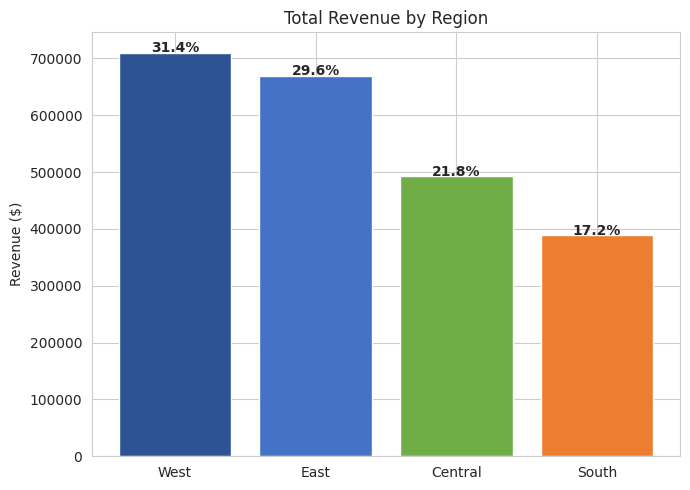

In [7]:
plt.figure(figsize=(7,5))
colors = ['#2e5395','#4472c4','#70ad47','#ed7d31']
bars = plt.bar(region.index, region['Revenue'], color=colors)
for bar, share in zip(bars, region['Revenue_Share_%']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
             f"{share}%", ha='center', fontsize=10, fontweight='bold')
plt.title("Total Revenue by Region")
plt.ylabel("Revenue ($)")
plt.tight_layout(); plt.show()


## 5. Category & Sub-Category Analysis

In [8]:
cat = df.groupby('Category')['Sales'].agg(['sum','mean','count']).round(2)
cat.columns = ['Revenue','Avg_Sale','Orders']
cat['Revenue_Share_%'] = (cat['Revenue']/cat['Revenue'].sum()*100).round(1)
cat


,Revenue,Avg_Sale,Orders,Revenue_Share_%
Category,,,,
Furniture,728658.58,350.65,2078,32.2
Office Supplies,705422.33,119.38,5909,31.2
Technology,827455.87,456.40,1813,36.6


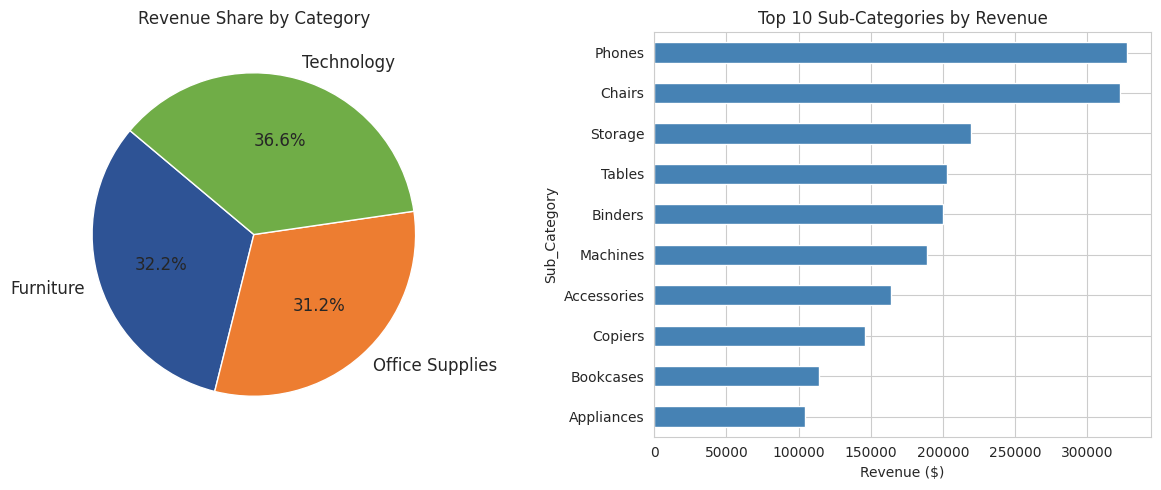

In [9]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].pie(cat['Revenue'], labels=cat.index, autopct='%1.1f%%',
            colors=['#2e5395','#ed7d31','#70ad47'], startangle=140, textprops={'fontsize':12})
axes[0].set_title("Revenue Share by Category")

subcat = df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False).head(10)
subcat.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title("Top 10 Sub-Categories by Revenue")
axes[1].set_xlabel("Revenue ($)")
plt.tight_layout(); plt.show()


## 6. Product Analysis

In [10]:
prod = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False)
print("TOP 10 PRODUCTS:")
print(prod.head(10).to_string())
print("\nBOTTOM 10 PRODUCTS:")
print(prod.tail(10).to_string())


TOP 10 PRODUCTS:
Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312

BOTTOM 10 PRODUCTS:
Product_Name
Stockwell Gold Paper Clips                    

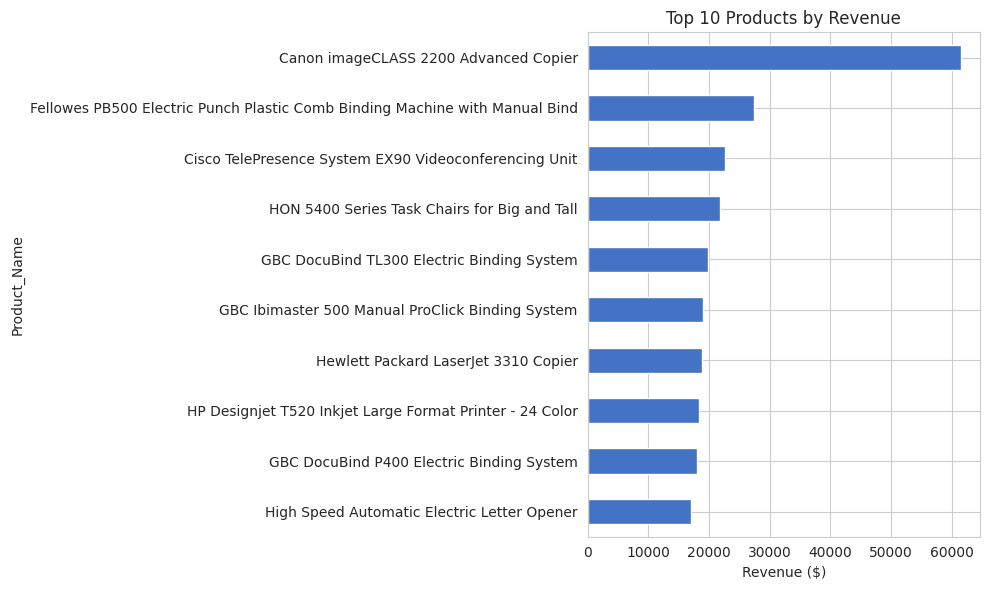

In [11]:
prod.head(10).sort_values().plot(kind='barh', figsize=(10,6), color='#4472c4')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue ($)")
plt.tight_layout(); plt.show()


## 7. Seasonality & Time Trends

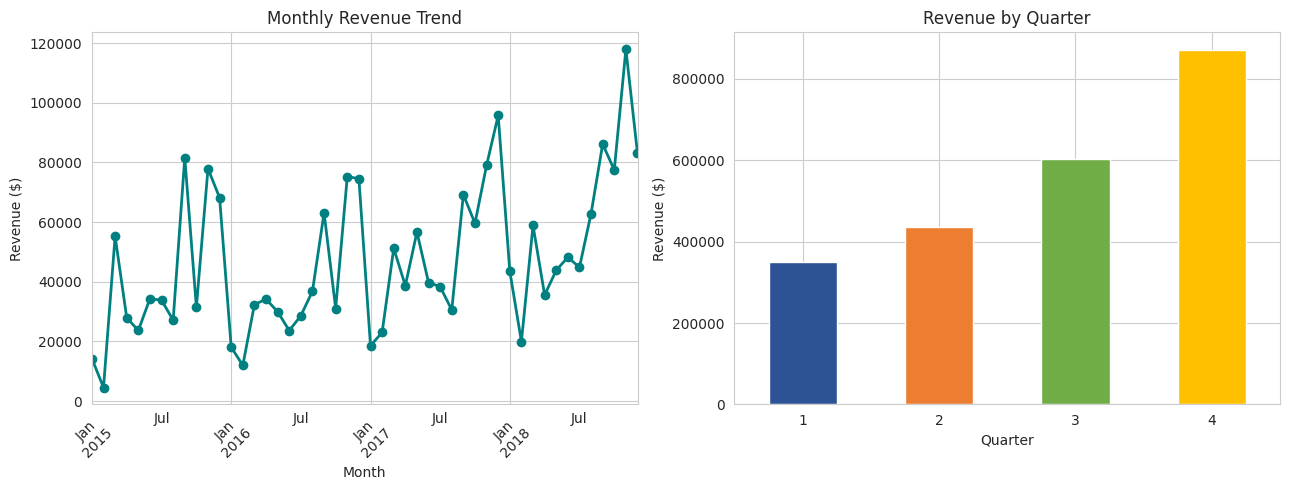

In [12]:
monthly = df.groupby('YearMonth')['Sales'].sum()
quarterly = df.groupby('Quarter')['Sales'].sum()

fig, axes = plt.subplots(1,2, figsize=(13,5))
monthly.plot(kind='line', marker='o', color='teal', linewidth=2, ax=axes[0])
axes[0].set_title("Monthly Revenue Trend")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Revenue ($)")
axes[0].tick_params(axis='x', rotation=45)

quarterly.plot(kind='bar', color=['#2e5395','#ed7d31','#70ad47','#ffc000'],
               edgecolor='white', ax=axes[1])
axes[1].set_title("Revenue by Quarter")
axes[1].set_xlabel("Quarter"); axes[1].set_ylabel("Revenue ($)")
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


In [13]:
print("Quarterly growth:")
for q in range(1,4):
    growth = (quarterly[q+1]-quarterly[q])/quarterly[q]*100
    print(f"  Q{q} -> Q{q+1}: +{growth:.1f}%")


Quarterly growth:
  Q1 -> Q2: +24.2%
  Q2 -> Q3: +38.2%
  Q3 -> Q4: +44.5%


## 8. Customer Segment Analysis

                Revenue  Avg_Sale  Orders  Revenue_Share_%
Segment                                                   
Consumer     1148060.53    225.07    5101             50.8
Corporate     688494.07    233.15    2953             30.4
Home Office   424982.18    243.40    1746             18.8


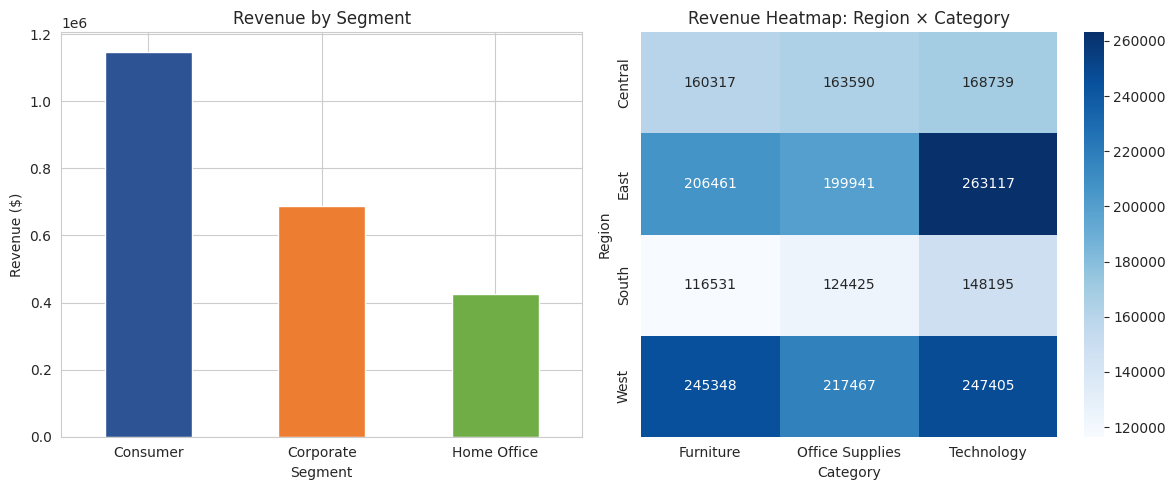

In [14]:
seg = df.groupby('Segment')['Sales'].agg(['sum','mean','count']).round(2)
seg.columns = ['Revenue','Avg_Sale','Orders']
seg['Revenue_Share_%'] = (seg['Revenue']/seg['Revenue'].sum()*100).round(1)
print(seg)

fig, axes = plt.subplots(1,2, figsize=(12,5))
seg['Revenue'].plot(kind='bar', color=['#2e5395','#ed7d31','#70ad47'],
                    edgecolor='white', ax=axes[0])
axes[0].set_title("Revenue by Segment"); axes[0].set_ylabel("Revenue ($)")
axes[0].tick_params(axis='x', rotation=0)

pivot = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='Blues', ax=axes[1])
axes[1].set_title("Revenue Heatmap: Region × Category")
plt.tight_layout(); plt.show()


## 9. Key Findings

- **West** is the top-performing region by revenue (~31%), followed by East (~30%). Central lags behind (~18%).
- **Technology** leads in average sale value despite fewer orders, while **Office Supplies** drives the highest order volume at low per-order revenue.
- **Strong Q4 seasonality**: Q4 revenue is ~2.5x Q1 — suggesting holiday/year-end purchasing peaks Alfido Tech should prepare for.
- **Consumer segment** accounts for ~51% of revenue but has the lowest average order value — Corporate and Home Office buyers spend more per order.
- **Top products** (e.g. Machines, Copiers) drive disproportionately large single-order revenue — retention of those buyers is critical.


## 10. Tactical Recommendations for Alfido Tech

1. **Invest marketing spend in the West & East ahead of Q4.** These two regions drive ~61% of revenue, and Q4 is consistently the strongest quarter (~38% of annual revenue). Targeted promotions in Aug–Sep can prime the pipeline before the year-end surge.

2. **Grow Corporate and Home Office segments.** Despite being smaller by headcount, these segments have higher average order values. B2B-focused campaigns, bulk discounts, and dedicated account managers can lift revenue without increasing order volume proportionally.

3. **Revive the Central region.** Central contributes only ~18% of revenue despite being a major US geography. Analyse whether this is a product fit issue or a marketing gap, and pilot a region-specific campaign with discounted shipping or category bundles.

4. **Double down on Technology — especially high-ticket sub-categories.** Copiers and Machines have the highest per-order revenue. A small improvement in win rate for these large deals has outsized impact on total revenue; dedicated sales support or financing options could help close more.

5. **Reduce ship times for Standard Class orders.** Standard Class is the most common ship mode but likely has the longest lead times. Faster fulfilment is a known driver of repeat purchases — even shaving 1–2 days off delivery for frequent Consumer segment buyers can meaningfully improve retention.
